# Paleoexfiltration Model: Complex Retreat-Readvance (Superposition)

In [1]:
# Importing necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Unit convention to carry throughout the rest of the code
YEAR = 3600 * 24 * 365.0   # seconds in a year; ensures this remain consistent throughout

### Model Physics

In [2]:
# Defining the equation for hydraulic conductivity 
def hydraulic_conductivity(perm, rhow=1000.0, g=9.81, mu_w=1e-3):
    return perm * rhow * g / mu_w

# Defining the diffusion timescale  
def tau_robel(perm, S, rhoi=920.0, rhow=1000.0, g=9.81, mu_w=1e-3):
    return np.pi * rhow * mu_w / (perm * rhoi**2 * g * S)

# Defining hydraulic diffusivity
def hydraulic_diffusivity(K, S):
    return K / S

# Converts values from m/s to mm/a for reporting
def to_mm_per_yr(q):
    return q * YEAR * 1000.0

# This helps to turn an age/thickness record into forward time and piecewise-constant thinning rates 
def interval_rates(age_kyr, thickness):
    age_kyr = np.asarray(age_kyr, dtype=float)
    thickness = np.asarray(thickness, dtype=float)
    order = np.argsort(-age_kyr)                  # oldest first
    age, H = age_kyr[order], thickness[order]
    t = (age[0] - age) * 1000.0 * YEAR            # forward time, seconds
    R = -np.diff(H) / np.diff(t)
    return t, H, R

# Calculates exfiltration flux for a thickness history
def exfiltration(age_kyr, thickness, kappa, S, xi,
                 rhoi=920.0, rhow=1000.0, t_eval=None, max_block=4_000_000):
    t, H, R = interval_rates(age_kyr, thickness)
    t_out = t if t_eval is None else np.asarray(t_eval, dtype=float)
    C = (1.0 - xi) * (rhoi / rhow) * np.sqrt(kappa * S / np.pi)
    n, m = len(t_out), len(R)
    q = np.empty(n)
    block = max(1, int(max_block // max(m, 1)))

    for lo in range(0, n, block):
        hi = min(lo + block, n)
        tb = t_out[lo:hi, None]
        lag_on = np.maximum(tb - t[None, :-1], 0.0) # Elapsed times since each interval STARTED
        lag_off = np.maximum(tb - t[None, 1:], 0.0) # Elapsed times since each interval ENDED
        W = 2.0 * (np.sqrt(lag_on) - np.sqrt(lag_off))
        q[lo:hi] = C * (W @ R)
    return t_out, q

# Put this in to help with plotting; q resonds as sqrt(t) immediately after each rate change, so a grid that samples only the nodes misses the sharpest part of every response
def dense_time_grid(t, per_interval=400):
    t = np.asarray(t, float)
    u = np.linspace(0.0, 1.0, per_interval, endpoint=False) ** 2
    pieces = [a + u * (b - a) for a, b in zip(t[:-1], t[1:])]
    pieces.append(np.array([t[-1]]))
    return np.unique(np.concatenate(pieces))

# Ensure the plotting is composed of piecewise-constant rate plots, instead of implying a smooth ramp between intervals 
def step_series(t, R):
    return np.repeat(np.asarray(t, float), 2)[1:-1], np.repeat(np.asarray(R, float), 2)

### Load the thickness time series (from Nichols et al. 2024)

In [3]:
# Load the record from Nichols et al. (2024)
file_path = 'retreatreadvancetimeseries.csv'
interpolated_df = pd.read_csv(file_path)
SITE_COL = 'Site '    
duration_tf = (interpolated_df.groupby(SITE_COL)
               .agg(Start_Age=('Age', 'max'),
                    End_Age=('Age', 'min'),
                    Duration=('Age', lambda x: x.max() - x.min()))
               .reset_index())
duration_tf.head()

site = 1
site_data = (interpolated_df[interpolated_df[SITE_COL] == site]
             .dropna(subset=['Age', 'Thickness'])
             .drop_duplicates(subset='Age')
             .sort_values('Age', ascending=False)      # oldest -> youngest
             .reset_index(drop=True))
print(f"Site {site}: {len(site_data)} points, "
      f"{site_data['Age'].min():.2f}-{site_data['Age'].max():.2f} kyr, "
      f"{site_data['Thickness'].min():.0f}-{site_data['Thickness'].max():.0f} m")
site_data.head()

Site 1: 38 points, 0.00-8.10 kyr, 0-300 m


,Site,Thickness,Age,longitude,latitude,Elevation (m asl)
0,1,300,8.1,-107.5,-75.25,350
1,1,295,8.0,-107.5,-75.25,345
2,1,290,7.9,-107.5,-75.25,340
3,1,285,7.8,-107.5,-75.25,335
4,1,280,7.7,-107.5,-75.25,330


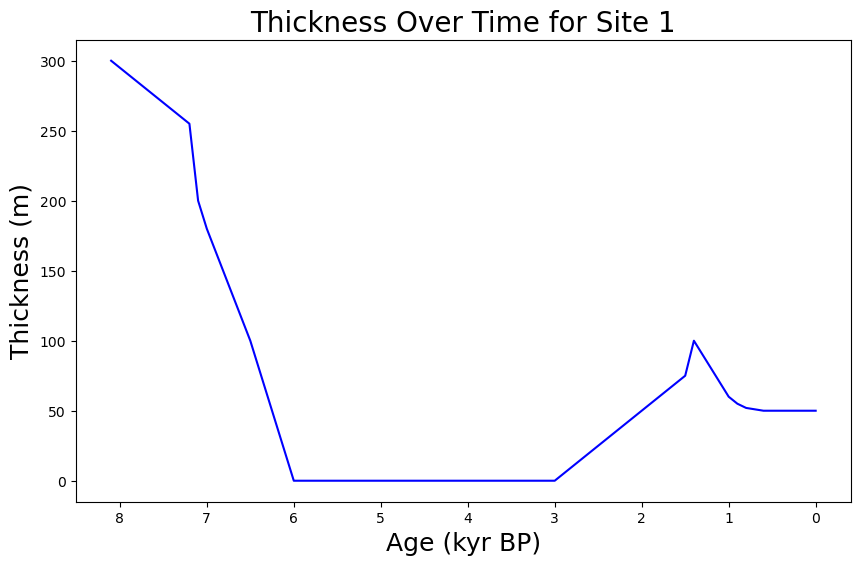

In [4]:
# Plot the forcing before running anything 
plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], site_data['Thickness'], color='blue')
plt.xlabel('Age (kyr BP)', fontsize=18)  # Increase the font size
plt.ylabel('Thickness (m)', fontsize=18)  # Increase the font size
plt.title(f'Thickness Over Time for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right
plt.show()

### Parameters and half-space validity

In [5]:
# Parameters 
rhoi = 920      # density of glacier ice (kg/m3)
rhow = 1000     # density of water (kg/m3)
g = 9.81        # gravity (m/s2)
mu_w = 1e-3     # viscosity of water (Pa s)
perm = 1e-13    # permeability (m2)
S = 1e-4        # specific storage (1/m)
xi = 0.2        # loading efficiency (Skempton)

# Record length in seconds, and the response timescale
K_t = hydraulic_conductivity(perm, rhow, g, mu_w)
tau = tau_robel(perm, S, rhoi, rhow, g, mu_w)

# Record length in seconds, and the response timescale
record_kyr = site_data['Age'].max() - site_data['Age'].min()
t_rec = record_kyr * 1000 * YEAR

# Hydraulic diffusivity. This is the quantity that governs HALF-SPACE VALIDITY.
# The Green's function assumes a semi-infinite aquifer, which holds only while
# the pressure signal has not reached the aquifer's lower boundary. 
D = hydraulic_diffusivity(K_t, S)

### Exfiltration

In [6]:
# Run the model on the Nichols et al. (2024) record; it evaluates flux at every output time (there is no time
# discretisation)
age_kyr = site_data['Age'].to_numpy(float)
thk = site_data['Thickness'].to_numpy(float)

# Forward time [s] from the oldest node and the piecewise-constant thinning rate on each interval (positive = thinning)
t_nodes, H_nodes, R = interval_rates(age_kyr, thk)

# Oldest age in years, used below to map forward time back to an age axis
age0_yr = age_kyr.max() * 1000.0

# Evaluate q on a DENSE grid rather than at the data nodes
t_dense = dense_time_grid(t_nodes, per_interval=400)
_, q_dense = exfiltration(age_kyr, thk, K_t, S, xi, t_eval=t_dense)
exf_dense = to_mm_per_yr(q_dense)

age_dense_yr = age0_yr - t_dense / YEAR

# Staircase of the forcing, for the second axis of the figure
t_step, R_step = step_series(t_nodes, R)

# R is in m/s and positive for thinning
dHdt_step = -R_step * YEAR * 1000.0
age_step_yr = age0_yr - t_step / YEAR


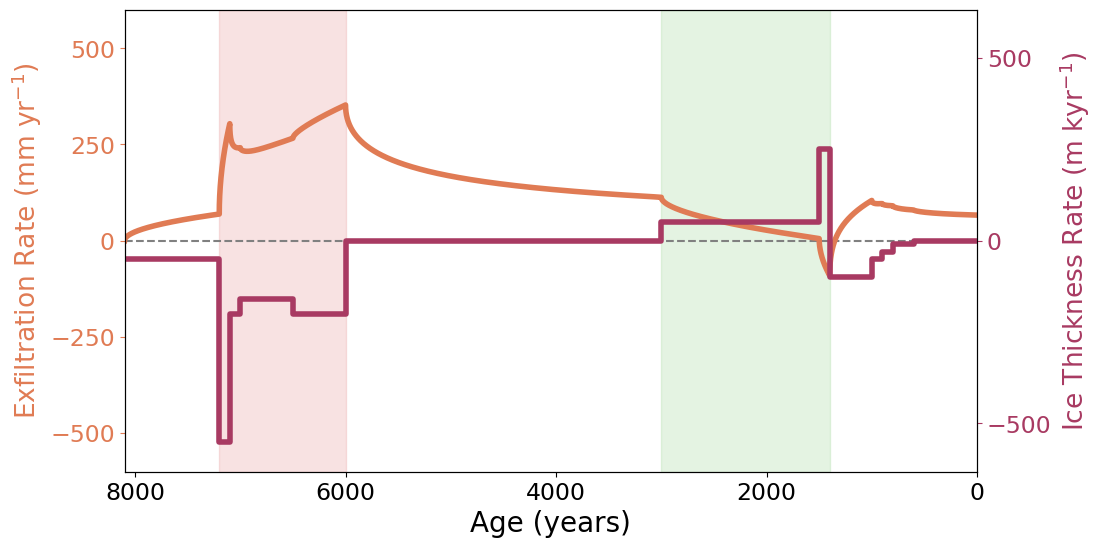

In [7]:
# Modeled exfiltration (left axis), against the thickness forcing (right axis)
line_width = 4
fig, ax1 = plt.subplots(figsize=(11, 6))

# Left axis
l1, = ax1.plot(age_dense_yr, exf_dense, '-', color="#E07B54", linewidth=line_width,
               label='Exfiltration rate')
ax1.set_xlabel('Age (years)', fontsize=20)
ax1.set_ylabel('Exfiltration Rate (mm yr$^{-1}$)', fontsize=19, color="#E07B54")
ax1.tick_params(axis='y', labelsize=17, colors="#E07B54")
ax1.tick_params(axis='x', labelsize=17)
ax1.set_xlim(8100, 0)
ax1.axhline(0, color='grey', linestyle='--', linewidth=1.5, zorder=1)
ax1.locator_params(axis='x', nbins=5)
ax1.locator_params(axis='y', nbins=5)

# Right axis
ax2 = ax1.twinx()
l2, = ax2.plot(age_step_yr, dHdt_step, '-', color="#A83A62", linewidth=line_width,
               label='Ice thickness rate (constant per interval)')
ax2.set_ylabel('Ice Thickness Rate (m kyr$^{-1}$)', fontsize=19, color="#A83A62")
ax2.tick_params(axis='y', labelsize=17, colors="#A83A62")
ax2.locator_params(axis='y', nbins=5)

ax1.set_ylim(-600, 600)
_m = np.max(np.abs(dHdt_step)) * 1.15
ax2.set_ylim(-_m, _m)

# Highlighted intervals
ax1.axvspan(7200, 6000, color='#E8A0A0', alpha=0.30, zorder=0)
ax1.axvspan(3000, 1400, color='#A8D8A0', alpha=0.30, zorder=0)

# # Labels for highlighted intervals
# ax1.text(7150, 580, 'a', fontsize=20, fontweight='bold',
#          ha='left', va='top')

# ax1.text(2950, 580, 'b', fontsize=20, fontweight='bold',
#          ha='left', va='top')
plt.savefig(
    "exfiltrationcomplexsuperposition.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
print(f"Minimum : {np.min(exf_dense):.3f} mm/yr")
print(f"Maximum : {np.max(exf_dense):.3f} mm/yr")
print(f"Mean    : {np.mean(exf_dense):.3f} mm/yr")

Minimum : -90.274 mm/yr
Maximum : 352.593 mm/yr
Mean    : 93.906 mm/yr
